# TD-06 - KMAXPP05

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## Afficheur digital

In [2]:
digits = np.array([
    [[1, 1], [0, 0]], # haut
    [[0, 0], [1, 1]], # bas
    [[1, 0], [1, 0]], # gauche
    [[0, 1], [0, 1]] # droite
])

In [3]:
def visualiser_valeurs(image, fontsize=12):
    image = image.reshape(-1, 2, 2)
    nb_lignes, nb_colonnes = image[0].shape
    n = image.shape[0]
    fig = plt.figure(figsize=(1.5 * n, 3))
    axes = fig.subplots(1, n)

    for i, ax in enumerate(axes):
        ax.imshow(np.zeros((nb_lignes, nb_colonnes)), cmap='Greys', vmin=0, vmax=1)
        for r in range(nb_lignes):
            for c in range(nb_colonnes):
                valeur = image[i, r, c]
                color_text = "k"
    
                ax.text(c, r, f"{valeur:.0f}",         # x=col, y=row
                        va='center', ha='center',  # Centrage parfait dans le pixel
                        fontsize=fontsize,         # Taille adaptée à la grille 3x5
                        color=color_text)
    
        ax.set_xticks([])
        ax.set_yticks([])
    
        ax.set_xticks(np.arange(-.5, nb_colonnes, 1), minor=True)
        ax.set_yticks(np.arange(-.5, nb_lignes, 1), minor=True)
        ax.grid(which='minor', color='#DDDDDD', linestyle='-', linewidth=1)
        ax.tick_params(which='minor', bottom=False, left=False) # Cacher les ticks de grille

In [4]:
def visualiser_chiffres(image):
    image = image.reshape(-1, 2, 2)
    n = image.shape[0]
    fig = plt.figure(figsize=(1.5 * n, 3))
    axes = fig.subplots(1, n)
    for i, ax in enumerate(axes):
        ax.imshow(image[i], cmap="cividis", vmin=0., vmax=1.)
        ax.set_xticks([])
        ax.set_yticks([]) 

In [5]:
def scree_plot(p, lbd, target=0.95):
    # Calculs
    fraction = lbd.cumsum() / lbd.sum()
    index = range(1, p+1)
    f = sp.interpolate.interp1d(fraction, index)
    index0 = f(target)
    # Création de la figure
    fig, ax1 = plt.subplots(figsize=(8, 5))
    # Tracé des valeurs propres
    line1 = ax1.plot(range(1, p+1), lbd, color="blue", label=r"$\lambda$")
    ax1.set_ylabel(r"$\lambda$")
    ax1.set_xlabel("Index")
    ax1.set_xlim(0, p+1)
    ax1.set_ylim(0, None)
    # Tracé de la fraction de variance
    ax2 = ax1.twinx()
    line2 = ax2.plot(index, fraction, color="orange", label=r"fraction de la somme des $\lambda$")
    cible = ax2.vlines(index0, ymin=0, ymax=target, ls="--", color="k", lw=1.0, label=f"fraction cible: {target:.2f}")
    ax2.hlines(target, xmin=index0, xmax=p+1, ls="--", color="k", lw=1.0)    
    ax2.set_ylabel(r"Fraction de la somme des $\lambda $")
    ax2.set_xlim(0, p+1)
    ax2.set_ylim(0, None)
    # Légende
    lines = line1 + line2 + [cible]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    plt.title("Éboulis des valeurs propres")

In [6]:
images = digits.reshape(-1, 4)

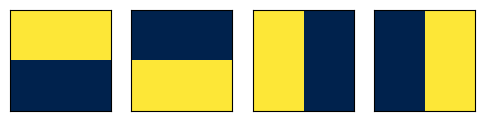

In [7]:
visualiser_chiffres(images)

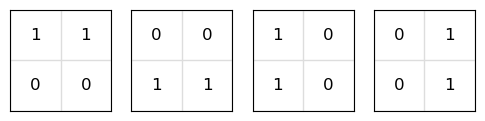

In [8]:
visualiser_valeurs(images)

Applatissement:

In [9]:
images = digits.reshape(-1, digits.shape[1] * digits.shape[2])

Calcul de l'image moyenne:

In [10]:
images_centrees = images - images.mean(axis=0)

In [11]:
images.mean(axis=0)

array([0.5, 0.5, 0.5, 0.5])

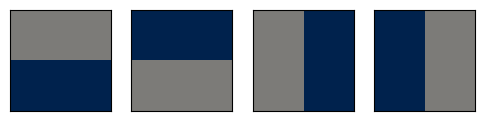

In [12]:
visualiser_chiffres(images_centrees)

In [13]:
images_centrees

array([[ 0.5,  0.5, -0.5, -0.5],
       [-0.5, -0.5,  0.5,  0.5],
       [ 0.5, -0.5,  0.5, -0.5],
       [-0.5,  0.5, -0.5,  0.5]])

In [14]:
corr = np.cov(images_centrees, rowvar=False, ddof=0)
valeurs_propres, vecteurs_propres = np.linalg.eigh(corr)
tri = np.argsort(valeurs_propres)[-1::-1]
lbd = valeurs_propres[tri]
u = vecteurs_propres[:, tri]

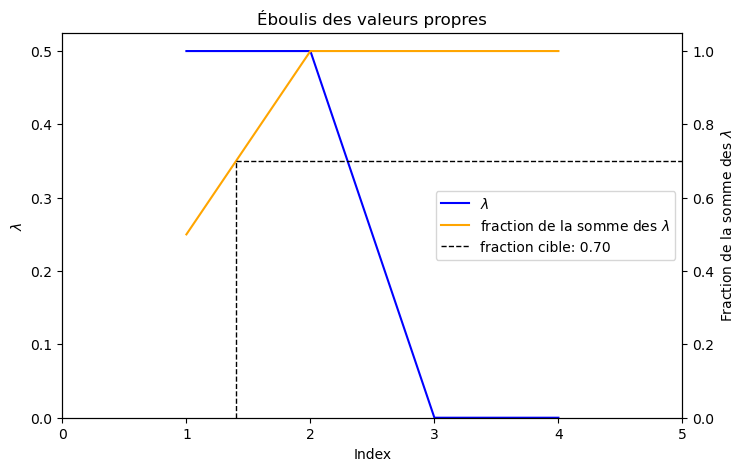

In [15]:
scree_plot(4, lbd, target=0.70)

In [16]:
lbd

array([0.5, 0.5, 0. , 0. ])

In [17]:
u

array([[-0.70710678,  0.        , -0.        , -0.70710678],
       [ 0.        ,  0.70710678, -0.70710678,  0.        ],
       [ 0.        , -0.70710678, -0.70710678,  0.        ],
       [ 0.70710678,  0.        ,  0.        , -0.70710678]])